# 03. Days from the promised delivery date: from OLS to Random Forest

**Purpose.** Predict, at order approval, by how many days an order will arrive before (negative) or after (positive) its promised delivery date. The lead time is capped at the 45-day waiting period, and predictions are clipped to that cap. We build the plain linear model properly first (transformations, variable selection judged on later time periods, coefficients with robust standard errors), then ask whether a Random Forest adds enough to justify its complexity. No model is chosen: every model is scored in exactly the same way on Train (in-sample), CV, Validation, Test (June) and Monitoring (July and August). The headline evaluation is June, and the primary metric is RMSE in days.

Regression has no resampling experiment and no reweighting (there is no class imbalance to correct).

**Contents**
1. Setup
2. Data and split
3. Baselines: R0a (median) and R0b (Olist promise)
4. Stage 1: linear models (transformations, R1, CV-stepwise R2, BIC/AIC stepwise R2B, Lasso, overlap, model key)
5. Stage 2: Random Forest (R3 tuned, R3d default)
6. Evaluation: Train, CV, Validation, June refit
7. Freeze and monitor: July and August
8. Results: comparison, late versus on-time errors, dual framing, success criteria, overfitting gaps, tuning gain, drift, predicted versus actual
9. Interpretation: OLS coefficients, hypothesis check, diagnostics, Random Forest importance
10. Exports and run metadata

**Model key.** Model codes (R0a, R1, ...) are the stable keys; every table also shows a readable `Model` column and every figure labels models "Code · short label". Section 4.7 shows the full key with the number of features each model uses (known once selection has run). The labels live in `src/model_labels.py` and the key is repeated in `RESULTS_SUMMARY.md`.

## 1. Setup

Imports, paths and constants. `RUN_RF_SEARCH = False` loads the cached Random Forest search (`python -m src.rf_search --task regression` produced it), so this notebook never re-runs the slow search.

In [1]:
import json
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
from IPython.display import Image, display
from sklearn.base import clone
from sklearn.dummy import DummyRegressor

from src import LOOKBACK, RANDOM_STATE
from src import evaluation as ev
from src import model_labels as ml
from src import model_figures as mf
from src.data import load_olist_data
from src.datasets import RUN_DATE, build_task_data
from src.features import LEAKAGE_COLS, add_extra_features, build_feature_table
from src.feature_selection import numeric_vif
from src.interpretation import (agreement_table, assert_coefficients_match, coefficient_table,
                                fit_statsmodels, hypothesis_check_table, plot_partial_dependence,
                                rf_partial_dependence, rf_permutation_importance)
from src.linear_transforms import linear_design, readable_names, skewness_table
from src.regression_models import PromiseBaseline, default_rf_pipeline, heteroscedasticity_table, score_cohort
from src.report_tables import export_report_tables
from src.rf_search import load_or_run_rf_search, plot_rf_sensitivity, search_space, tuned_rf_pipeline
from src.variable_selection import (forward_stepwise_cv, forward_stepwise_ic, lasso_units,
                                    make_unit_pipeline_builder, one_se_rule, selection_overlap,
                                    units_through_step)

RUN_RF_SEARCH = False
TASK = 'regression'
SCORING = 'neg_root_mean_squared_error'
OUT = Path('results/simple_to_complex/regression')
FIG = Path('results/simple_to_complex/figures')
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 40, 'display.width', 200)

## 2. Data and split

`build_task_data` returns the identical Train, Validation, full-history rows and 5 chronological CV folds used by every notebook and by the Random Forest search. Train holds buffered development rows (approved before the 45-day gap preceding Validation, with outcomes known); canceled and unavailable orders are excluded because they have no delivery outcome. Validation is the 30-day out-of-time holdout. The history is every known-outcome order before the run date (2 June 2018) and is used only to refit the fixed specifications for June. The target `y` is the lead time (capped at 45 days) minus the promised lead time, in days.

In [2]:
olist = load_olist_data(verbose=False)
orders = olist['orders']
final_df = add_extra_features(build_feature_table(olist), olist)
data = build_task_data(TASK, final_df)
FEATURES = data.feature_cols
assert not set(FEATURES) & set(LEAKAGE_COLS), 'Outcome columns used as features'
assert not data.train_ids & set(data.validation_df['order_id']), 'Train and Validation overlap'
assert data.train_df['order_approved_dt'].max() < data.validation_df['order_approved_dt'].min()
assert data.history_df['order_approved_dt'].max() < pd.Timestamp(RUN_DATE)
print(f'{len(FEATURES)} raw features ({len(data.num_cols)} numeric, {len(data.cat_cols)} categorical)')

24 raw features (21 numeric, 3 categorical)


In [3]:
def split_row(name, frame):
    return {'Split': name, 'Orders': len(frame), 'Mean days from promise': round(frame['y'].mean(), 2),
            'Median days': frame['y'].median(), 'SD days': round(frame['y'].std(), 2),
            'Late orders (> 0 days)': int((frame['y'] > 0).sum()), 'Late rate (%)': round(100 * (frame['y'] > 0).mean(), 2),
            'First approval': frame['order_approved_dt'].min().date(),
            'Last approval': frame['order_approved_dt'].max().date()}

row_counts = pd.DataFrame([split_row('Train', data.train_df), split_row('Validation', data.validation_df),
                           split_row('History before 2 June (June refit)', data.history_df)])
fold_sizes = pd.DataFrame([{'Fold': k, 'CV training rows': len(tr), 'CV validation rows': len(va),
                            'Mean days in CV validation': round(data.y_train.iloc[va].mean(), 2)}
                           for k, (tr, va) in enumerate(data.folds, 1)])
row_counts.to_csv(OUT / 'row_counts.csv', index=False)
display(row_counts)
display(fold_sizes)

,Split,Orders,Mean days from promise,Median days,SD days,Late orders (> 0 days),Late rate (%),First approval,Last approval
0,Train,45371,-11.44,-13.0,9.16,3426,7.55,2017-04-18,2018-02-01
1,Validation,6847,-9.78,-11.0,9.46,686,10.02,2018-03-19,2018-04-17
2,History before 2 June (June refit),62841,-10.51,-12.0,9.66,6161,9.80,2017-04-18,2018-04-17


,Fold,CV training rows,CV validation rows,Mean days in CV validation
0,1,10697,4358,-11.35
1,2,14711,4291,-11.13
2,3,18961,7700,-7.95
3,4,23309,5202,-12.82
4,5,27919,7133,-12.63


The figure below (written by notebook 01) shows the five expanding chronological CV folds, the 45-day gaps and the Validation block. `01_validation_timeline.png` shows the full timeline including Test (June) and Monitoring.

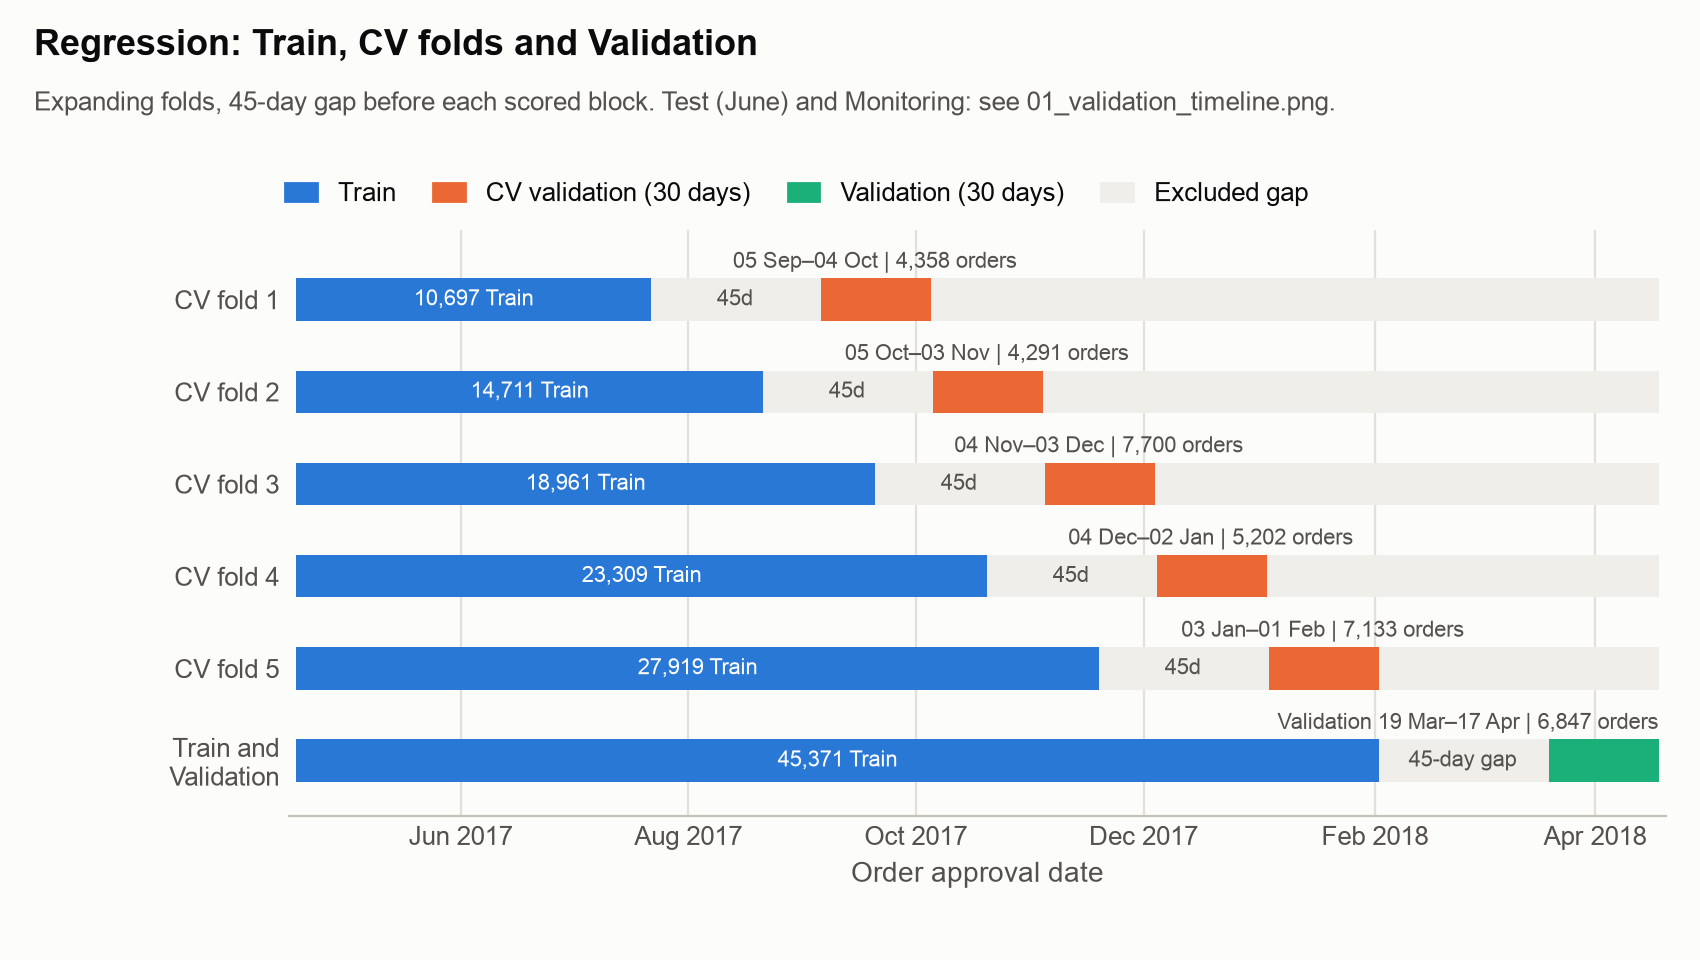

In [4]:
display(Image(Path('results/simple_to_complex/figures/01_cv_folds_regression.png'), width=900))

## 3. Baselines: R0a and R0b

Two floors every model has to beat. **R0a** (`DummyRegressor(strategy='median')`) predicts the Train median days from the promise for every order. **R0b**, the Olist promise (`PromiseBaseline`), predicts delivery exactly on the promised date, i.e. 0 days: it is the error of taking the marketplace's own estimate at face value. All predictions are clipped to the waiting period with `clip_to_waiting_period`, so no model can predict a lead time below 0 days or above 45 days.

In [5]:
r0a = DummyRegressor(strategy='median').fit(data.X_train, data.y_train)
print(f'R0a predicts {r0a.predict(data.X_train.head(1))[0]:.1f} days for every order (before clipping); '
      f'R0b predicts 0 days.')

R0a predicts -13.0 days for every order (before clipping); R0b predicts 0 days.


## 4. Stage 1: plain linear models

### 4.1 The route-type merge

In Train, the 118 orders with `route_type == '3. Mixed'` and the 227 orders with `seller_state_count >= 2` contain **no late orders**. That is quasi-separation for the logistic models in notebook 02, and every linear model in this notebook uses the same design so that the two tasks are comparable: `merge_mixed_route=True` folds `3. Mixed` into `1. All interstate` (every mixed-route order has at least one interstate leg). OLS can estimate a coefficient for each level even without late orders, so nothing breaks here; the merge only keeps the feature definitions identical across tasks. `seller_state_count` stays in the feature set. The Random Forest uses the raw 24 features unchanged.

### 4.2 Transformations (pre-specified, linear models only)

The linear models always use the same transformations, fixed before any model is fitted from the predictors' distributions and the cyclic nature of month and weekday. They are not tuned on the outcome: variable selection (sections 4.4 to 4.6) is the only outcome-driven step. Trees are invariant to monotone transforms, so the Random Forest does not need any of this.

- **log1p on the 8 skewed inputs** (money, size, time and load variables). They are non-negative with long right tails (|skew| from 1.7 to 11.2 on Train, table above). log1p compresses the tail so a few extreme orders do not dominate a linear fit, handles zeros, and turns effects into per-doubling (multiplicative) terms that are easy to read. The choice used only the predictors' distribution on Train, never the outcome, so it adds no selection optimism; pre-specifying transformations is recommended by Harrell, *Regression Modeling Strategies*.
- **Sine and cosine for month and weekday.** They are cyclic: December is next to January and Sunday next to Monday, whereas a plain number imposes a false straight-line order and a jump at the wrap-around. Dummies would be exactly collinear with the weekend and December flags, and a sine/cosine pair captures a smooth seasonal cycle in two columns.
- **No squared terms.** Choosing polynomial terms by looking at the outcome would be another data-driven selection step; keeping variable selection as the only outcome-driven step keeps the method simple and avoids extra optimism. Each coefficient stays a single, interpretable slope, and any remaining nonlinearity is what the Random Forest stage tests, so the linear-versus-Random-Forest comparison is where nonlinearity is judged.
- **Why not other transformations?**
  - *Exponential and other expanding transforms (squares, powers above 1).* The skewed inputs already have long right tails; an expanding transform stretches the tail further and gives a few extreme orders even more leverage in a linear fit, the opposite of what is needed. It is also numerically unstable on money and volume values (exp of a payment value overflows).
  - *Quadratic and polynomial terms.* Choosing curvature terms by looking at the outcome is a second outcome-driven selection step, which adds optimism (specification search). The curvature diagnostic shows no strong curvature remains, and any remaining nonlinearity is tested by the Random Forest stage.
  - *Box-Cox and Yeo-Johnson.* These estimate a power per feature from the data. log1p is the simplest member of that family (Box-Cox lambda = 0, shifted by 1 to handle zeros) and gives readable "per doubling" effects. Fitting a lambda per feature adds parameters and makes coefficients harder to interpret, for little expected gain once the log has already reduced the skew.
  - *Splines and binning.* These are flexible, outcome-shaped terms. Flexible nonlinearity is exactly what the Random Forest stage is for, so the linear stage stays a simple, interpretable baseline.
  - *Principle.* Transformations are chosen from each input's distribution and for interpretability, not by searching over transformation families against the outcome, so variable selection remains the only outcome-driven step.

In [6]:
SKEW_CANDIDATES = ['payment_value_sum', 'order_frieght_value_sum', 'order_product_weight_g_sum',
                   'order_product_volume_cm3_sum', 'approval_lag_hours', 'seller_dist_km_mean',
                   'freight_to_price_ratio', 'orders_approved_prev_7d']
skew = skewness_table(data.train_df, SKEW_CANDIDATES)
LOG_COLS = skew.loc[skew['log1p_recommended'], 'feature'].tolist()
skew.round(2).to_csv(OUT / 'skewness_train.csv', index=False)
display(skew.round(2))

,feature,min,skew_raw,skew_log1p,non_negative,log1p_recommended
0,payment_value_sum,10.07,11.35,0.56,True,True
1,order_frieght_value_sum,0.00,9.01,1.19,True,True
2,order_product_weight_g_sum,0.00,6.70,0.39,True,True
3,order_product_volume_cm3_sum,288.00,8.22,-0.04,True,True
4,approval_lag_hours,0.09,4.02,0.97,True,True
5,seller_dist_km_mean,0.00,1.68,-1.10,True,True
6,freight_to_price_ratio,0.00,3.74,1.90,True,True
7,orders_approved_prev_7d,417.00,1.73,0.68,True,True


In [7]:
LINEAR_OPTIONS = dict(log_cols=LOG_COLS, cyclic=True, merge_mixed_route=True)


def build_ols(units=FEATURES):
    """Unfitted plain OLS pipeline on `units` with the pre-specified linear design."""
    return make_unit_pipeline_builder(TASK, data.num_cols, data.cat_cols, **LINEAR_OPTIONS)(units)

### Curvature check (diagnostic only)

Binned partial residuals (the OLS residual plus the term's fitted contribution, in days) for the three strongest numeric predictors (largest |t| in a statsmodels OLS on the pre-specified design, numeric columns with at least 20 distinct values). A straight line through the bin means supports a linear term. The plot is a diagnostic only: it does not change the design, and no squared terms are added. The promised-lead-days and log seller-distance bins lie close to the straight line, and log approval lag shows only mild scatter at its low end, so the pre-specified design leaves no strong curvature. Any remaining nonlinearity is left to the Random Forest comparison.

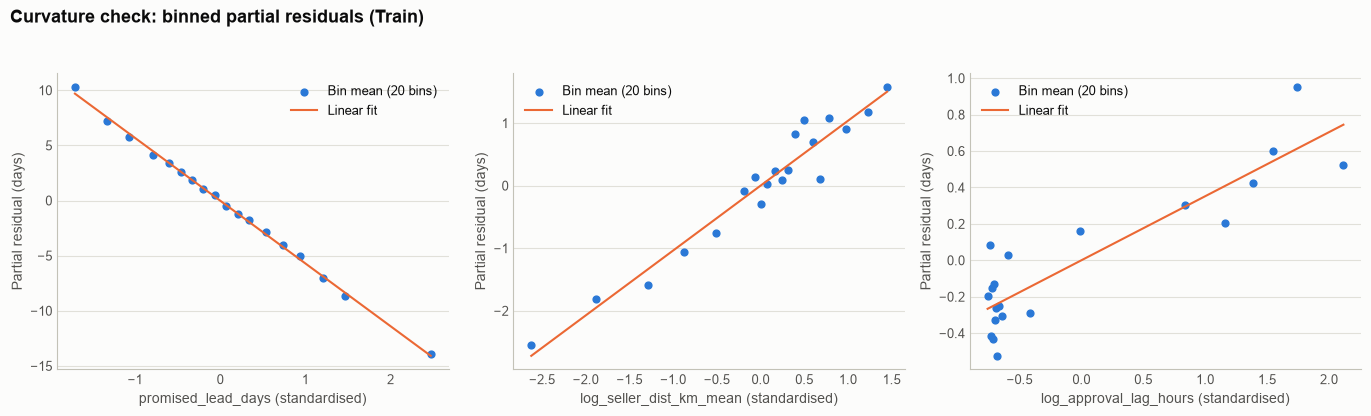

In [8]:
design, _, pre = linear_design(data.train_df, data.num_cols, data.cat_cols, **LINEAR_OPTIONS)
sm_probe = fit_statsmodels(TASK, design, data.y_train)
probe = coefficient_table(sm_probe, TASK, pre, data.cat_cols)
continuous = [c for c in data.num_cols if data.X_train[c].nunique() >= 20]  # enough values for 20 bins
numeric_terms = probe[probe['kind'].isin(['numeric', 'log']) & probe['unit'].isin(continuous)]
top_terms = numeric_terms.assign(abs_t=numeric_terms['statistic'].abs()).nlargest(3, 'abs_t')
mf.plot_partial_residuals(sm_probe, design, data.y_train, top_terms['term'].tolist(),
                          FIG / '03_curvature_partial_residuals.png', ylabel='Partial residual (days)')
plt.show()

In [9]:
numeric_design = design[[c for c in design.columns if design[c].nunique() > 2]]
linear_vif = numeric_vif(numeric_design).rename('vif').reset_index().rename(columns={'index': 'column'})
linear_vif.sort_values('vif', ascending=False).to_csv(OUT / 'linear_design_vif.csv', index=False)
display(linear_vif.sort_values('vif', ascending=False).head(8).round(2))

,column,vif
12,log_payment_value_sum,6.23
7,log_order_frieght_value_sum,6.21
17,log_freight_to_price_ratio,4.20
8,log_order_product_weight_g_sum,3.33
15,log_order_product_volume_cm3_sum,2.54
6,order_seller_count,2.29
10,log_seller_dist_km_mean,2.20
4,order_approved_month_cos,2.12


**Variance inflation on the final design.** The table lists the largest VIFs among numeric columns of the final linear design. Sine and cosine terms are paired by construction, so any high value should be read together with its partner column.

### 4.3 R1: OLS on all 24 features

Ordinary least squares (`LinearRegression`) on the pre-specified transformations: no penalty, no tuning. CV here is not tuning: it gives an honest estimate of out-of-time performance. Mean and SD are over the 5 chronological folds, with predictions clipped to the waiting period. R1's CV and later scores come from the evaluation in section 6.

In [10]:
r1_spec = build_ols()

### 4.4 CV-stepwise selection with the 1-SE rule: R2

Forward selection from an intercept-only model. Each step tries every remaining raw feature (the three categoricals move as whole dummy blocks; transformed variants travel with their raw feature) and adds the one with the lowest mean chronological-CV RMSE. Every addition is judged on later, unseen time periods rather than on in-sample p-values, which limits the usual stepwise overfitting. The 1-SE rule then picks the smallest step whose mean CV RMSE is within one standard error of the best step. (The stepwise path scores unclipped predictions; clipping only matters for the final evaluation.)

In [11]:
build_units = make_unit_pipeline_builder(TASK, data.num_cols, data.cat_cols, **LINEAR_OPTIONS)
cv_path, cv_candidates = forward_stepwise_cv(
    data.train_df, data.y_train, FEATURES, build_units, data.folds, SCORING, data.train_ids, n_jobs=-1)
chosen_step, best_step = one_se_rule(cv_path)
R2_UNITS = units_through_step(cv_path, chosen_step)
rmse_path = cv_path.assign(cv_mean=-cv_path['cv_mean'])
rmse_path.to_csv(OUT / 'stepwise_path.csv', index=False)
cv_candidates.assign(cv_mean=-cv_candidates['cv_mean']).to_csv(OUT / 'stepwise_candidates.csv', index=False)
print(f'Best CV step {best_step}; 1-SE step {chosen_step}')
print('R2 units in order of entry:', R2_UNITS)
display(rmse_path.rename(columns={'cv_mean': 'cv_rmse'}).round(4))

Best CV step 16; 1-SE step 1
R2 units in order of entry: ['promised_lead_days']


,step,added_unit,n_units,n_encoded_columns,cv_rmse,cv_se
0,0,(intercept only),0,0,9.3402,0.3566
1,1,promised_lead_days,1,1,8.6168,0.5185
2,2,customer_state,2,27,8.4187,0.5465
3,3,seller_dist_km_mean,3,28,8.3828,0.5454
4,4,order_product_weight_g_sum,4,29,8.3699,0.5439
5,5,order_seller_count,5,30,8.3579,0.5437
6,6,order_approved_day_of_week,6,32,8.3539,0.5415
7,7,approval_lag_hours,7,33,8.3501,0.5403
8,8,payment_combination,8,37,8.3470,0.5382
9,9,is_weekend_approval,9,38,8.3451,0.5381


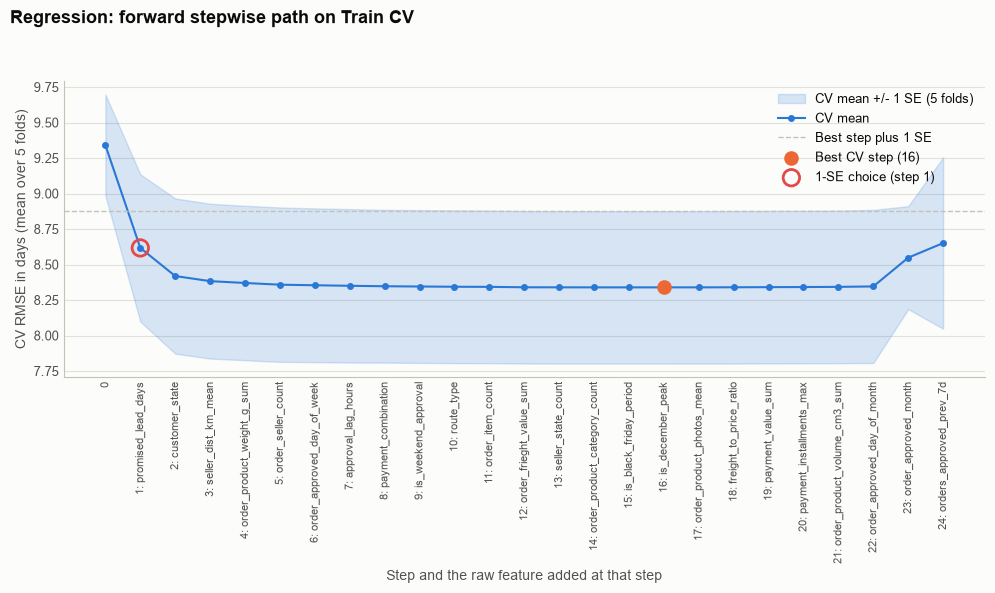

In [12]:
mf.plot_stepwise_path(rmse_path, chosen_step, best_step, 'CV RMSE in days (mean over 5 folds)',
                      FIG / '03_stepwise_path.png', title='Regression: forward stepwise path on Train CV',
                      higher_is_better=False)
plt.show()

### 4.5 Information-criterion cross-check: R2B

The same forward procedure, but each candidate is scored in-sample on Train by BIC (stop when no addition lowers it) with statsmodels `OLS`; AIC is also run and only its selected set is reported. This is the classical, likelihood-based approach: fast, no folds, but it assumes independent rows and a stable relationship over time. Agreement with CV-stepwise is evidence of robustness.

In [13]:
def design_builder(rows):
    design, unit_columns, _ = linear_design(rows, data.num_cols, data.cat_cols, **LINEAR_OPTIONS)
    return design, unit_columns


bic_path, BIC_UNITS = forward_stepwise_ic(data.train_df, data.y_train, FEATURES, design_builder, TASK,
                                          data.train_ids, criterion='bic')
aic_path, AIC_UNITS = forward_stepwise_ic(data.train_df, data.y_train, FEATURES, design_builder, TASK,
                                          data.train_ids, criterion='aic')
bic_path.to_csv(OUT / 'ic_path_bic.csv', index=False)
aic_path.to_csv(OUT / 'ic_path_aic.csv', index=False)
print('BIC units:', BIC_UNITS)
print('AIC units:', AIC_UNITS)
display(bic_path.round(1))

BIC units: ['promised_lead_days', 'customer_state', 'is_black_friday_period', 'seller_dist_km_mean', 'order_approved_month', 'order_product_weight_g_sum', 'order_seller_count', 'is_december_peak', 'order_approved_day_of_week', 'route_type', 'order_item_count', 'order_frieght_value_sum', 'order_product_photos_mean', 'approval_lag_hours', 'order_product_volume_cm3_sum', 'orders_approved_prev_7d', 'is_weekend_approval']
AIC units: ['promised_lead_days', 'customer_state', 'is_black_friday_period', 'seller_dist_km_mean', 'order_approved_month', 'order_product_weight_g_sum', 'order_seller_count', 'is_december_peak', 'order_approved_day_of_week', 'route_type', 'order_item_count', 'order_frieght_value_sum', 'order_product_photos_mean', 'approval_lag_hours', 'payment_combination', 'order_product_volume_cm3_sum', 'orders_approved_prev_7d', 'seller_state_count', 'is_weekend_approval', 'order_product_category_count', 'payment_installments_max', 'freight_to_price_ratio']


,step,added_unit,k,aic,bic,method
0,0,(intercept only),0,329756.1,329764.8,ols
1,1,promised_lead_days,1,321778.9,321796.3,ols
2,2,customer_state,27,319012.9,319257.1,ols
3,3,is_black_friday_period,28,318033.6,318286.5,ols
4,4,seller_dist_km_mean,29,317620.1,317881.7,ols
5,5,order_approved_month,31,317120.6,317399.7,ols
6,6,order_product_weight_g_sum,32,316932.9,317220.7,ols
7,7,order_seller_count,33,316763.7,317060.3,ols
8,8,is_december_peak,34,316671.9,316977.1,ols
9,9,order_approved_day_of_week,36,316600.8,316923.6,ols


### 4.6 Lasso cross-check and the overlap table

`LassoCV` on the same design and folds, with the penalty chosen by mean CV error over its default grid. A categorical block is kept if any of its dummies is non-zero. Lasso adds a column to the overlap table only; it gets no model row.

In [14]:
lasso = lasso_units(data.train_df, data.y_train, FEATURES, design_builder, TASK, data.folds, data.train_ids)
overlap = selection_overlap(FEATURES, cv_path, chosen_step, BIC_UNITS, AIC_UNITS, lasso['selected_units'])
overlap.to_csv(OUT / 'selection_overlap.csv', index=False)
print(f"Lasso penalty alpha = {lasso['penalty']:.4g}; {len(lasso['selected_units'])} units kept")
display(overlap)

Lasso penalty alpha = 0.2421; 13 units kept


,unit,cv_stepwise,cv_step_entered,bic,aic,lasso,n_methods
0,promised_lead_days,True,1,True,True,True,4
1,customer_state,False,2,True,True,True,3
2,seller_dist_km_mean,False,3,True,True,True,3
3,order_seller_count,False,5,True,True,True,3
4,order_approved_day_of_week,False,6,True,True,True,3
5,approval_lag_hours,False,7,True,True,True,3
6,order_item_count,False,11,True,True,True,3
7,order_frieght_value_sum,False,12,True,True,True,3
8,is_black_friday_period,False,15,True,True,True,3
9,is_december_peak,False,16,True,True,True,3


### 4.7 Model key

Every model in this notebook, with the number of raw features it uses. The OLS subsets are the selections above; the Random Forests use all raw features.

In [15]:
n_features = {'R1': len(FEATURES), 'R2': len(R2_UNITS), 'R2B': len(BIC_UNITS), 'R3': len(FEATURES), 'R3d': len(FEATURES)}
display(ml.model_key_table(ml.REGRESSION_CODES, n_features))

,Code,Model,Description,Features
0,R0a,Median baseline,Predicts the Train median days from promise fo...,-
1,R0b,Olist promise,Predicts arrival exactly on the promised date ...,-
2,R1,OLS (all),"Ordinary least squares, all 24 features, pre-s...",24
3,R2,OLS (CV-stepwise),"OLS, features chosen by CV forward stepwise wi...",1
4,R2B,OLS (BIC),"OLS, features chosen by BIC forward stepwise",17
5,R3,Random Forest (tuned),"Random Forest, raw 24 features, hyperparameter...",24
6,R3d,Random Forest (default),"Random Forest, raw 24 features, scikit-learn d...",24


## 5. Stage 2: Random Forest

The forest works on the raw 24 features (no transformations). The wide two-stage search (Stage A: 60 random candidates with 200 trees; Stage B: a neighbourhood grid around the Stage A best with 300 or 500 trees) was run once from `python -m src.rf_search` on Train with the same 5 folds, scored by RMSE (`criterion='squared_error'`). Ties go to the simpler forest. This notebook only loads the cached result.

**R3d** is the untuned baseline: `RandomForestRegressor(random_state=42, n_jobs=-1)` with scikit-learn defaults, on the same raw features and reference-coded preprocessor. The defaults are 100 trees, fully grown trees (`max_depth=None`, `min_samples_leaf=1`, `min_samples_split=2`), `max_features=1.0` (all features at every split), `criterion='squared_error'` and bootstrap sampling with full-size samples. The comparison of R3 with R3d shows what tuning buys.

In [16]:
rf_search = load_or_run_rf_search(TASK, run=RUN_RF_SEARCH, data=data)
RF_PARAMS = rf_search['best_params']
meta = rf_search['metadata']
r3_spec = tuned_rf_pipeline(TASK, RF_PARAMS, data.num_cols, data.cat_cols)
space = pd.DataFrame({'parameter': list(search_space(TASK)),
                      'values searched (Stage A)': [', '.join(map(str, v)) for v in search_space(TASK).values()]})
summary = pd.DataFrame([
    ('Stage A candidates', meta['n_iter_stage_a']), ('Stage A trees', meta['stage_a_trees']),
    ('Stage B candidates', meta['stage_b_candidates']), ('Stage B trees', ' or '.join(map(str, meta['stage_b_trees']))),
    ('Best CV RMSE, days (mean +/- SD)', f"{-meta['best_cv_mean']:.3f} +/- {meta['best_cv_sd']:.3f}"),
    ('Stage A best CV RMSE, days', f"{-meta['stage_a_best_cv_mean']:.3f}"),
    ('Search time (Stage A + B, s)', round(meta['stage_a_seconds'] + meta['stage_b_seconds'])),
    ('Best parameters', json.dumps(RF_PARAMS))], columns=['Item', 'Value'])
top_candidates = rf_search['stage_b'].head(5).assign(cv_rmse=lambda f: -f['mean_score']).round(4)
display(space)
display(summary)
display(top_candidates)

,parameter,values searched (Stage A)
0,max_depth,"None, 6, 8, 10, 12, 16, 20, 30"
1,min_samples_leaf,"1, 2, 5, 10, 20, 50, 100, 200"
2,min_samples_split,"2, 5, 10, 20, 50"
3,max_features,"log2, sqrt, 0.2, 0.3, 0.5, 0.7, 1.0"
4,max_samples,"None, 0.5, 0.7, 0.9"


,Item,Value
0,Stage A candidates,60
1,Stage A trees,200
2,Stage B candidates,36
3,Stage B trees,300 or 500
4,"Best CV RMSE, days (mean +/- SD)",8.335 +/- 0.819
5,"Stage A best CV RMSE, days",8.353
6,"Search time (Stage A + B, s)",532
7,Best parameters,"{""min_samples_split"": 50, ""max_samples"": 0.9, ..."


,max_depth,max_features,max_samples,min_samples_leaf,min_samples_split,n_estimators,mean_score,sd_score,mean_fit_time,mean_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,cv_rmse
0,NaN,0.3,0.9,2,50,500,-8.3354,0.8193,18.1547,0.2262,-7.3751,-7.4181,-9.4175,-8.9627,-8.5038,8.3354
1,30.0,0.3,0.9,2,50,500,-8.3364,0.8194,17.6394,0.2491,-7.3753,-7.4189,-9.4155,-8.9683,-8.5039,8.3364
2,NaN,0.3,0.9,2,50,300,-8.3390,0.8152,11.6897,0.1725,-7.3849,-7.4208,-9.4136,-8.9570,-8.5188,8.3390
3,30.0,0.3,0.9,2,50,300,-8.3398,0.8152,10.2222,0.1354,-7.3841,-7.4214,-9.4086,-8.9658,-8.5188,8.3398
4,30.0,0.3,0.9,1,50,500,-8.3437,0.8214,16.9836,0.2306,-7.3603,-7.4248,-9.4135,-8.9483,-8.5715,8.3437


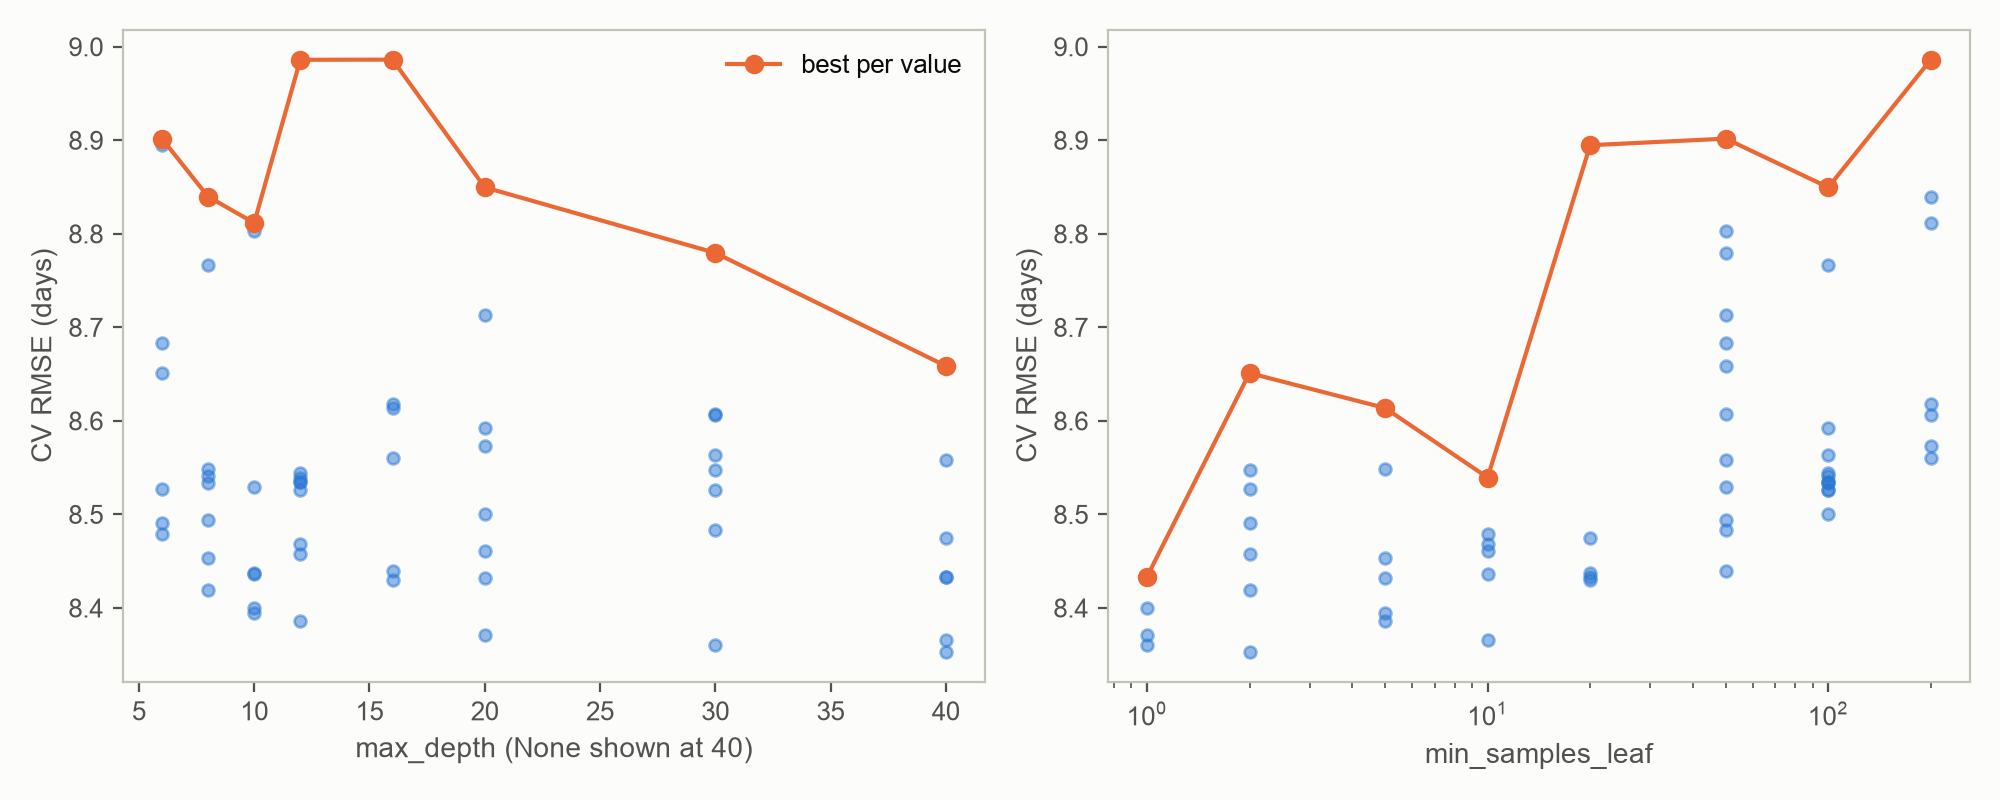

In [17]:
plot_rf_sensitivity(rf_search['stage_a'], TASK, FIG / '03_rf_sensitivity.png')
display(Image(FIG / '03_rf_sensitivity.png'))

## 6. Evaluation: Train, CV, Validation and the June refit

Every model uses the same procedure:
1. Fit on Train; score Train (in-sample) and Validation. Validation is for diagnostics only; no choice uses it.
2. Chronological CV on Train (mean and SD over 5 folds).
3. Refit the **fixed specification** (same transformations, same selected variables, same forest parameters) on the full known-outcome history before 2 June, then score June daily with `run_inference` and pool the daily scores before computing metrics.

All predictions are clipped with `clip_to_waiting_period` before scoring. June, July and August include only orders whose target is known at approval day + 45 days; canceled and unavailable orders are excluded as in Train. Besides the regression metrics, each row records the late flag (prediction > 0 days) against the classification label for the dual-framing diagnostic.

In [18]:
SPECS = {'R0a': DummyRegressor(strategy='median'),
         'R0b': PromiseBaseline(),
         'R1': r1_spec,
         'R2': build_units(R2_UNITS),
         'R2B': build_units(BIC_UNITS),
         'R3': r3_spec,
         'R3d': default_rf_pipeline(data.num_cols, data.cat_cols)}

In [19]:
train_fits, result_rows, cv_parts = {}, [], []
validation_days = {}
for label, spec in SPECS.items():
    fitted = clone(spec).fit(data.X_train, data.y_train)
    train_fits[label] = fitted
    validation_days[label] = score_cohort(fitted, data.validation_df, FEATURES)
    result_rows.append(ev.score_regression_split(label, 'Train', data.y_train,
                                                 score_cohort(fitted, data.train_df, FEATURES),
                                                 data.train_df['late_label']))
    result_rows.append(ev.score_regression_split(label, 'Validation', data.y_validation,
                                                 validation_days[label], data.validation_df['late_label']))
    cv_parts.append(ev.cv_regression_metrics(spec, data.X_train, data.y_train, data.folds).assign(model=label))
cv_folds = pd.concat(cv_parts, ignore_index=True)
print('Fitted and cross-validated:', ', '.join(SPECS))

Fitted and cross-validated: R0a, R0b, R1, R2, R2B, R3, R3d


In [20]:
history = data.history_df
june_fits, june_scored, fingerprints = {}, {}, {}
for label, spec in SPECS.items():
    june_fits[label] = clone(spec).fit(history[FEATURES], history['y'])
    fingerprints[label] = {'before_june': ev.fingerprint(june_fits[label])}
    june_scored[label] = ev.score_regression_months(june_fits[label], final_df, orders, FEATURES, ['2018-06'])['2018-06']

june_ids = june_scored['R0a']['order_id'].tolist()
june_targets = june_scored['R0a']['actual_target']
for label, frame in june_scored.items():
    assert frame['order_id'].tolist() == june_ids, f'{label} scored different June orders'
    assert frame['actual_target'].equals(june_targets), f'{label} received different June targets'
assert not set(june_ids) & set(history['order_id']), 'June orders leaked into the history'
for label, frame in june_scored.items():
    result_rows.append(ev.score_regression_split(label, 'June', frame['actual_target'],
                                                 frame['predicted_days'], frame['actual_label']))
june_summary = pd.Series({'scored orders': len(june_ids), 'known targets': int(june_targets.notna().sum()),
                          'late orders (> 0 days)': int((june_targets.dropna() > 0).sum())})
display(june_summary.to_frame('June (Test)').T)

,scored orders,known targets,late orders (> 0 days)
June (Test),6142,6142,116


## 7. Freeze and monitor: July and August

Each June-fitted model is frozen: its learned state is hashed (SHA-256 fingerprint) before and after scoring, and the fingerprints must be identical across June, July and August (no refit, retune, reselection or re-transformation). July and August are Monitoring months scored by the same frozen models.

In [21]:
monitoring = {}
for label, fitted in june_fits.items():
    monitoring[label] = ev.score_regression_months(fitted, final_df, orders, FEATURES, ['2018-07', '2018-08'])
    fingerprints[label]['after_august'] = ev.fingerprint(fitted)
    assert fingerprints[label]['before_june'] == fingerprints[label]['after_august'], f'{label} changed'
    for month, name in [('2018-07', 'July'), ('2018-08', 'August')]:
        frame = monitoring[label][month]
        result_rows.append(ev.score_regression_split(label, name, frame['actual_target'],
                                                     frame['predicted_days'], frame['actual_label']))
results = pd.DataFrame(result_rows)
results['model'] = pd.Categorical(results['model'], list(SPECS)).astype(str)
results.to_csv(OUT / 'model_results_long.csv', index=False)
cv_folds.to_csv(OUT / 'cv_fold_scores.csv', index=False)
fingerprint_table = pd.DataFrame({label: {'fingerprint': f['before_june'][:16], 'unchanged after August': f['before_june'] == f['after_august']}
                                  for label, f in fingerprints.items()}).T
display(ml.add_model_columns(fingerprint_table.rename_axis('model').reset_index()))

,Code,Model,fingerprint,unchanged after August
0,R0a,Median baseline,aa458ba0e06a2f8c,True
1,R0b,Olist promise,1c7d431dae39804d,True
2,R1,OLS (all),9ce863baacab0c19,True
3,R2,OLS (CV-stepwise),1d4a2bce23922601,True
4,R2B,OLS (BIC),eee2e4eda2e33db1,True
5,R3,Random Forest (tuned),e966d2bf96e28d62,True
6,R3d,Random Forest (default),7cd4ce93d7a827e4,True


## 8. Results

### 8.1 Full model comparison

Columns: Train (in-sample), CV mean +/- SD over 5 chronological folds, Validation, **June (Test, headline)**, and July and August (Monitoring). All errors are in days. RMSE is the primary metric (lower is better); bias is the mean of prediction minus actual, so a negative bias means the model predicts deliveries earlier than they happen. The cohort differs by split, so compare models within a column.

In [22]:
METRICS = [('rmse', 'RMSE, days (primary; lower is better)'), ('mae', 'MAE, days'), ('r2', 'R-squared'),
           ('median_ae', 'Median absolute error, days'), ('bias', 'Bias (prediction minus actual), days')]
comparison_tables = {title: ml.add_model_columns(ev.comparison_table(results, cv_folds, metric), code_col='Model')
                     for metric, title in METRICS}
for title, table in comparison_tables.items():
    print(title)
    display(table)
cohort_rates = results.pivot(index='model', columns='split', values='late_rate').loc[
    :, ['Train', 'Validation', 'June', 'July', 'August']].iloc[[0]].round(4)
display(cohort_rates.rename(index={'R0a': 'Share of scored orders that are late'}))

RMSE, days (primary; lower is better)


,Code,Model,Train,CV mean +/- SD,Validation,June,July,August
0,R0a,Median baseline,9.115,9.265 +/- 1.022,9.864,11.688,8.162,8.416
1,R0b,Olist promise,14.426,14.255 +/- 1.237,13.550,20.888,13.994,11.739
2,R1,OLS (all),7.895,8.651 +/- 1.349,8.205,7.369,7.302,6.479
3,R2,OLS (CV-stepwise),8.384,8.614 +/- 1.163,8.926,9.373,7.353,6.385
4,R2B,OLS (BIC),7.899,8.635 +/- 1.371,8.204,7.374,7.283,6.472
5,R3,Random Forest (tuned),6.780,8.310 +/- 0.934,8.397,7.953,7.453,7.497
6,R3d,Random Forest (default),2.950,8.710 +/- 1.014,8.556,8.393,8.283,8.288


MAE, days


,Code,Model,Train,CV mean +/- SD,Validation,June,July,August
0,R0a,Median baseline,6.100,6.324 +/- 0.725,6.733,9.163,5.467,5.906
1,R0b,Olist promise,13.012,12.810 +/- 1.300,11.867,19.299,12.261,8.923
2,R1,OLS (all),5.336,5.911 +/- 0.827,5.625,5.806,5.237,4.462
3,R2,OLS (CV-stepwise),5.765,5.829 +/- 0.857,6.156,8.035,5.344,3.994
4,R2B,OLS (BIC),5.341,5.888 +/- 0.831,5.626,5.811,5.219,4.453
5,R3,Random Forest (tuned),4.535,5.696 +/- 0.889,5.675,6.447,5.308,5.187
6,R3d,Random Forest (default),2.000,6.290 +/- 1.066,6.059,6.804,6.198,6.013


R-squared


...

Median absolute error, days


,Code,Model,Train,CV mean +/- SD,Validation,June,July,August
0,R0a,Median baseline,4.000,4.400 +/- 0.548,5.000,8.000,4.000,5.000
1,R0b,Olist promise,13.000,12.800 +/- 1.304,11.000,19.000,11.000,7.000
2,R1,OLS (all),3.825,4.173 +/- 0.683,4.008,5.037,4.187,3.432
3,R2,OLS (CV-stepwise),4.278,4.172 +/- 0.674,4.290,7.467,4.176,2.612
4,R2B,OLS (BIC),3.836,4.143 +/- 0.638,4.005,5.039,4.150,3.424
5,R3,Random Forest (tuned),3.170,4.162 +/- 0.907,3.864,5.828,4.125,3.695
6,R3d,Random Forest (default),1.390,4.807 +/- 1.251,4.410,6.050,4.910,4.410


Bias (prediction minus actual), days


,Code,Model,Train,CV mean +/- SD,Validation,June,July,August
0,R0a,Median baseline,-1.515,-1.785 +/- 1.911,-3.022,7.153,-0.324,-2.509
1,R0b,Olist promise,11.333,11.055 +/- 1.890,9.745,18.821,11.136,7.643
2,R1,OLS (all),0.000,-1.119 +/- 2.700,-0.260,4.097,2.391,2.131
3,R2,OLS (CV-stepwise),-0.002,-1.186 +/- 1.374,-0.713,6.662,2.705,1.478
4,R2B,OLS (BIC),0.000,-1.158 +/- 2.638,-0.257,4.099,2.362,2.121
5,R3,Random Forest (tuned),0.035,-0.539 +/- 1.088,-0.714,4.943,2.556,1.719
6,R3d,Random Forest (default),0.148,0.567 +/- 1.696,0.300,5.280,3.779,3.607


split,Train,Validation,June,July,August
model,,,,,
Share of scored orders that are late,0.0763,0.1006,0.0189,0.0444,0.0729


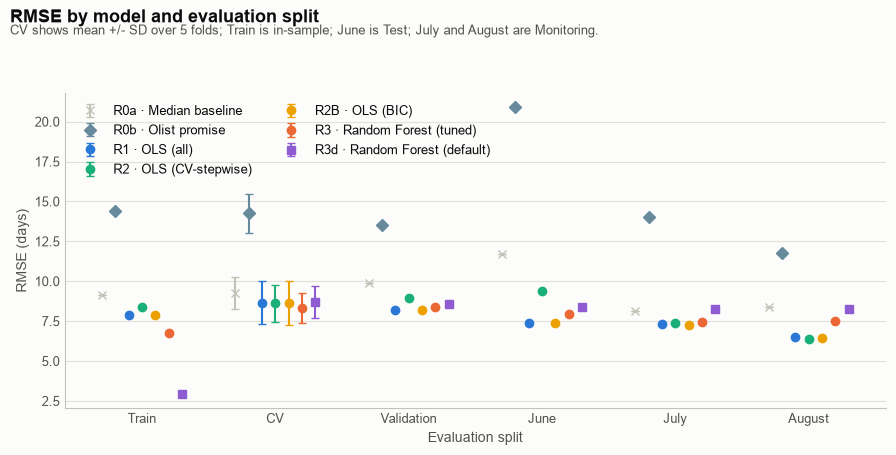

In [23]:
labels = list(SPECS)
cv_mean, cv_sd = ev.cv_mean_sd(cv_folds)
wide_rmse = results.pivot(index='model', columns='split', values='rmse').loc[labels]
values = pd.concat([wide_rmse[['Train']], cv_mean.loc[labels, ['rmse']].rename(columns={'rmse': 'CV'}),
                    wide_rmse[['Validation', 'June', 'July', 'August']]], axis=1)
sds = pd.DataFrame(np.nan, index=values.index, columns=values.columns)
sds['CV'] = cv_sd.loc[labels, 'rmse']
mf.plot_model_comparison(values, 'RMSE (days)', sds, FIG / '03_model_comparison_rmse.png',
                         title='RMSE by model and evaluation split',
                         subtitle='CV shows mean +/- SD over 5 folds; Train is in-sample; June is Test; July and August are Monitoring.')
plt.show()

### 8.2 Errors for late versus on-time orders

The same RMSE and MAE computed separately for orders that turned out to be late (the classification label is 1) and on time. A model that is good on average but poor on late orders is of little use for flagging problems, so this split matters more than the pooled number.

In [24]:
def flat(table):
    """Flatten two-level column headers and put the model Code and label first."""
    table = table.copy()
    table.columns = [' '.join(c) for c in table.columns]
    return ml.add_model_columns(table.reset_index())


error_split = flat(ev.error_split_table(results).round(3))
display(error_split)

,Code,Model,Validation RMSE late,Validation MAE late,Validation RMSE on-time,Validation MAE on-time,June RMSE late,June MAE late,June RMSE on-time,June MAE on-time
0,R0a,Median baseline,24.854,23.418,6.251,4.866,26.169,24.405,11.232,8.876
1,R0b,Olist promise,13.433,10.546,13.564,12.017,15.775,12.672,20.988,19.453
2,R1,OLS (all),20.936,18.952,5.076,4.132,25.560,23.566,6.503,5.444
3,R2,OLS (CV-stepwise),23.048,21.417,5.398,4.447,25.255,23.680,8.776,7.723
4,R2B,OLS (BIC),20.931,18.947,5.077,4.134,25.600,23.614,6.504,5.449
5,R3,Random Forest (tuned),21.605,19.844,5.115,4.089,25.320,23.320,7.196,6.108
6,R3d,Random Forest (default),20.640,18.576,5.807,4.657,24.799,22.545,7.714,6.483


### 8.3 Dual framing: the derived late flag against the classification label

Flag an order as late when the predicted days from the promise exceed 0 and compare it with the late label of notebook 02 (same definition, same cut-off). This asks how a regression model performs as a late-delivery classifier at its natural threshold, without any tuning of the threshold. Precision is the share of flagged orders that are late; recall is the share of late orders flagged.

In [25]:
late_flag = flat(ev.late_flag_table(results).round(3))
display(late_flag)

,Code,Model,Validation Precision,Validation Recall,Validation F1,June Precision,June Recall,June F1
0,R0a,Median baseline,0.000,0.000,0.000,0.000,0.000,0.000
1,R0b,Olist promise,0.000,0.000,0.000,0.000,0.000,0.000
2,R1,OLS (all),0.500,0.010,0.020,0.000,0.000,0.000
3,R2,OLS (CV-stepwise),0.000,0.000,0.000,0.000,0.000,0.000
4,R2B,OLS (BIC),0.467,0.010,0.020,0.000,0.000,0.000
5,R3,Random Forest (tuned),0.000,0.000,0.000,0.000,0.000,0.000
6,R3d,Random Forest (default),0.132,0.038,0.059,0.128,0.043,0.065


### 8.4 Success criteria and overfitting gaps

Criteria: RMSE at least 10% below the median baseline R0a, and RMSE below the Olist promise R0b. `value` is the relative RMSE reduction against that reference. The Random Forests' relative RMSE gain over the better of the OLS models R1 and R2 is reported on the same split (no pass/fail threshold). Overfitting gap = Train (in-sample) minus CV mean; a negative RMSE gap means Train error is below CV error.

In [26]:
criteria = ev.regression_success_criteria(results, ['R1', 'R2'], ['R3', 'R3d'])
criteria_display = ml.add_model_columns(
    criteria.assign(value=criteria['value'].round(3), threshold=criteria['threshold'].round(3),
                    passed=criteria['passed'].map({True: 'pass', False: 'fail'}).fillna('reported')))
display(criteria_display)
gap_metrics = ['rmse', 'mae', 'r2', 'bias']
gaps = ml.add_model_columns(ev.overfitting_gaps(results, cv_folds, gap_metrics).round(4))
display(gaps)

,Code,Model,split,criterion,value,threshold,passed
0,R1,OLS (all),June,RMSE >= 10% below R0a,0.370,0.1,pass
1,R1,OLS (all),June,RMSE below R0b,0.647,0.0,pass
2,R2,OLS (CV-stepwise),June,RMSE >= 10% below R0a,0.198,0.1,pass
3,R2,OLS (CV-stepwise),June,RMSE below R0b,0.551,0.0,pass
4,R2B,OLS (BIC),June,RMSE >= 10% below R0a,0.369,0.1,pass
5,R2B,OLS (BIC),June,RMSE below R0b,0.647,0.0,pass
6,R3,Random Forest (tuned),June,RMSE >= 10% below R0a,0.320,0.1,pass
7,R3,Random Forest (tuned),June,RMSE below R0b,0.619,0.0,pass
8,R3d,Random Forest (default),June,RMSE >= 10% below R0a,0.282,0.1,pass
9,R3d,Random Forest (default),June,RMSE below R0b,0.598,0.0,pass


,Code,Model,rmse,mae,r2,bias
0,R0a,Median baseline,-0.1499,-0.2246,0.0349,0.2702
1,R0b,Olist promise,0.1708,0.2021,-0.0157,0.2782
2,R1,OLS (all),-0.7556,-0.5747,0.1506,1.1188
3,R2,OLS (CV-stepwise),-0.2301,-0.0648,0.0467,1.1838
4,R2B,OLS (BIC),-0.7358,-0.5471,0.1466,1.1580
5,R3,Random Forest (tuned),-1.5297,-1.1609,0.2749,0.5745
6,R3d,Random Forest (default),-5.7608,-4.2898,0.8022,-0.4199


### 8.5 Does tuning the Random Forest help? R3 versus R3d

Tuned minus default for each metric on CV, Validation and June (negative is better for RMSE and MAE, positive is better for R-squared), plus both forests' Train minus CV gaps.

In [27]:
tuning_gain = ev.tuning_gain_table(results, cv_folds, 'R3', 'R3d', ['rmse', 'mae', 'r2'])
display(tuning_gain.round(4))

,metric,CV: R3,CV: R3d,CV: gain,Validation: R3,Validation: R3d,Validation: gain,June: R3,June: R3d,June: gain,Train - CV gap: R3,Train - CV gap: R3d
0,rmse,8.3095,8.7104,-0.4008,8.3975,8.5563,-0.1588,7.9533,8.3931,-0.4399,-1.5297,-5.7608
1,mae,5.6956,6.2901,-0.5944,5.6754,6.0589,-0.3835,6.4473,6.8037,-0.3565,-1.1609,-4.2898
2,r2,0.1774,0.0942,0.0832,0.2114,0.1813,0.0301,0.2861,0.2049,0.0812,0.2749,0.8022


### 8.6 Drift: June to July to August

The frozen models are scored on later months without refitting. RMSE is read together with the share of late orders and the bias, because the average delivery delay itself moves between months.

,Code,Model,metric,June,July,August,change_june_to_last
0,R0a,Median baseline,rmse,11.6879,8.1623,8.4157,-3.2721
1,R0a,Median baseline,mae,9.1631,5.4673,5.9063,-3.2569
2,R0a,Median baseline,bias,7.1527,-0.3244,-2.5086,-9.6613
3,R0a,Median baseline,late_rate,0.0189,0.0444,0.0729,0.0540
4,R0b,Olist promise,rmse,20.8877,13.9944,11.7393,-9.1484
5,R0b,Olist promise,mae,19.2994,12.2614,8.9229,-10.3765
6,R0b,Olist promise,bias,18.8207,11.1361,7.6435,-11.1772
7,R0b,Olist promise,late_rate,0.0189,0.0444,0.0729,0.0540
8,R1,OLS (all),rmse,7.3692,7.3021,6.4791,-0.8900
9,R1,OLS (all),mae,5.8058,5.2375,4.4620,-1.3437


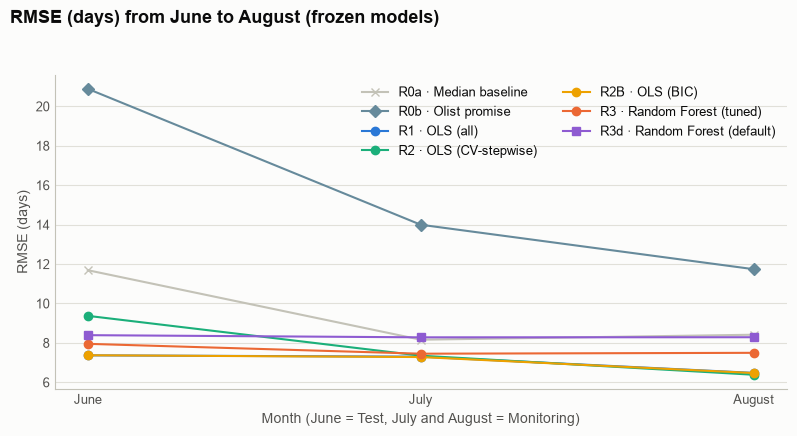

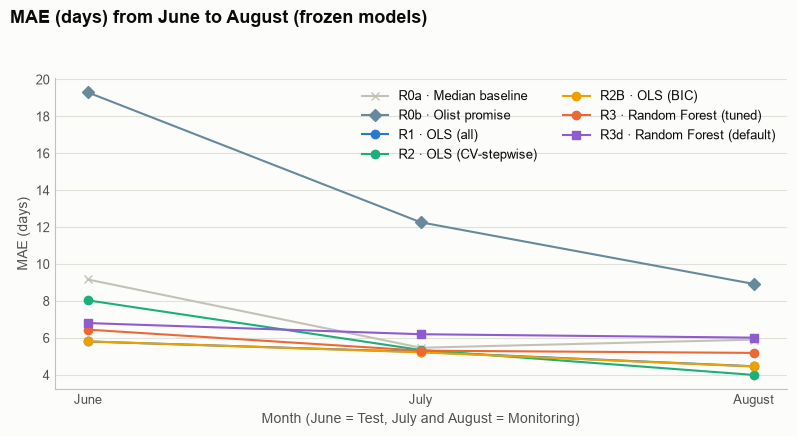

In [28]:
drift = ev.drift_table(results, ['rmse', 'mae', 'bias', 'late_rate'])
drift.round(4).to_csv(OUT / 'drift_long.csv', index=False)
drift_view = ml.add_model_columns(drift.round(4))
display(drift_view)
for metric, ylabel in [('rmse', 'RMSE (days)'), ('mae', 'MAE (days)')]:
    mf.plot_drift(drift, metric, ylabel, save_path=FIG / f'03_drift_{metric}.png')
    plt.show()

### 8.7 Predicted versus actual

June (Test) predictions against the actual days from the promised date for the full OLS model R1, the stepwise model R2 and the tuned forest R3. Points on the dashed diagonal are exact. A model that only predicts the typical early arrival gives a horizontal band.

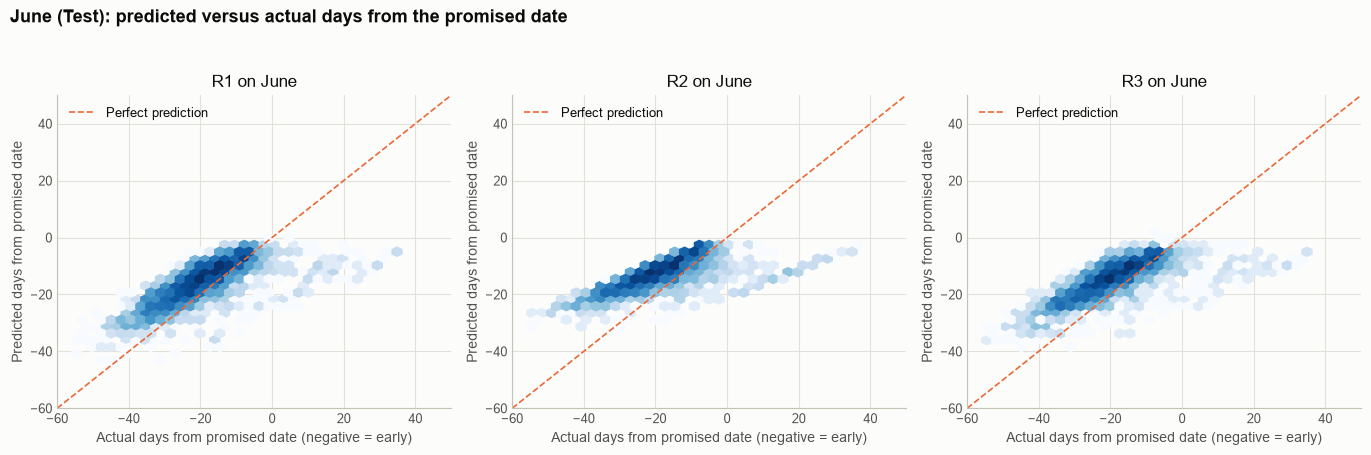

In [29]:
known_june = june_scored['R0a'].dropna(subset=['actual_target'])
known_index = known_june.index
panels = {f'{label} on June': (june_scored[label].loc[known_index, 'actual_target'].astype(float),
                               june_scored[label].loc[known_index, 'predicted_days'])
          for label in ['R1', 'R2', 'R3']}
mf.plot_predicted_vs_actual(panels, FIG / '03_predicted_vs_actual.png',
                            title='June (Test): predicted versus actual days from the promised date')
plt.show()

**Reading the results (June is the headline).**
- **Every model beats both baselines.** June RMSE (days): R0a 11.69, R0b 20.89, R1 7.37, R2B 7.37, R3 7.95, R3d 8.39, R2 9.37. All five fitted models pass both criteria on June (RMSE at least 10% below the median baseline, and below the Olist promise); on Validation R2 narrowly fails the 10% criterion (9.5% below R0a). The Olist promise is a poor point forecast: its error is the typical early arrival (bias +9.7 days on Validation), so promised dates are conservative.
- **Does the Random Forest justify itself?** Not on RMSE. The tuned forest has the lowest CV RMSE (8.31 versus 8.65 for R1), but the difference is well inside the fold-to-fold SD (about 1 to 1.3), and the forest is worse than the full OLS model R1 on Validation (8.40 versus 8.21, a relative gain of -2.3%) and on June (7.95 versus 7.37, -7.9%). The plain linear model is competitive out of time, as in classification.
- **Selection.** The 1-SE rule keeps a single variable (`promised_lead_days`): CV RMSE 8.62 against 8.34 at the best step (16 variables). The whole possible improvement (0.28 days) is smaller than one SE (about 0.54), so the rule stops at step 1. R2 matches R1 on CV (8.61 versus 8.65) but is clearly worse on Validation (8.93 versus 8.21) and June (9.37 versus 7.37), where the extra variables (state, distance, seasonality) matter. BIC selects 17 of 24 variables and performs the same as R1 (R2B and R1 differ by less than 0.02 days of RMSE on every split); Lasso keeps 13. `promised_lead_days` is the only variable chosen by all four methods.
- **Errors are driven by late orders.** For R1 on June the RMSE is 25.6 days on the 116 late orders but 6.5 days on on-time orders, and every model except R0b has a late-order MAE of 22 to 24 days. The Olist promise has the smallest late-order error (13.4 days RMSE on Validation) only because it predicts 0 days; it is by far the worst on on-time orders (13.6 days versus 5.1 for R1).
- **Dual framing.** With the natural cut-off of 0 days the derived late flag is almost never raised: the models predict early arrival for nearly every order, so recall is at most 4% (R3d, F1 0.07 on June), and R1, R2, R2B and R3 flag no June order correctly. R0a and R0b flag nothing. Predicting the conditional mean is a different job from ranking late risk; use the classification notebook for flagging.
- **Overfitting.** Train minus CV RMSE gaps: R3d -5.76, R3 -1.53, R1 -0.76, R2B -0.74, R2 -0.23. The default forest memorises Train (RMSE 2.95, R-squared 0.90 against 0.09 in CV). Tuning (section 8.5) lowers RMSE by 0.40 on CV, 0.16 on Validation and 0.44 on June and shrinks the gap from -5.76 to -1.53.
- **Drift.** The linear models improve after June (R1 RMSE 7.37, 7.30 and 6.48 in June, July and August), the tuned forest does not (7.95, 7.45, 7.50) and the default forest stays near 8.3. The June bias is positive for every fitted model (R1 +4.1 days, R3 +4.9): June deliveries were later than the training period implied; it shrinks to about +2 days afterwards. The late share rises from 1.9% to 4.4% and 7.3%, which is why the baselines' RMSE falls so much (R0a 11.69 to 8.42).

## 9. Interpretation

### 9.1 OLS coefficients with robust standard errors (R1 and R2)

Each linear model is refitted with statsmodels `OLS` on the identical Train design, with HC3 heteroscedasticity-robust standard errors (the residual diagnostics below show why). The assertion checks that the statsmodels coefficients equal scikit-learn's, which holds because the fit is the same least-squares problem. Numeric inputs are standardised for modelling; the tables give effects in days **per unit** (original scale; for log inputs, **per doubling**) and **per 1 SD**. A negative effect means earlier arrival relative to the promise. Categorical effects are relative to their reference (state SP, route `1. All interstate`, single-method `credit_card`). Sine/cosine terms have no per-unit reading.

In [30]:
sm_results, coef_tables, coefficient_checks = {}, {}, {}
for label in ['R1', 'R2']:
    fitted = train_fits[label]
    pre = fitted.named_steps['preprocessor']
    design = pd.DataFrame(pre.transform(data.X_train), columns=readable_names(pre), index=data.train_df.index)
    result = fit_statsmodels(TASK, design, data.y_train)
    gap = assert_coefficients_match(fitted, result)
    sm_results[label], coef_tables[label] = result, coefficient_table(result, TASK, pre, data.cat_cols)
    coefficient_checks[label] = {'max_abs_gap': gap, 'n_terms': len(result.params), 'covariance': 'HC3'}
    coef_tables[label].to_csv(OUT / f'{label}_coefficients.csv', index=False)
print(json.dumps(coefficient_checks, indent=1))

{
 "R1": {
  "max_abs_gap": 1.865174681370263e-13,
  "n_terms": 55,
  "covariance": "HC3"
 },
 "R2": {
  "max_abs_gap": 6.084022174945858e-14,
  "n_terms": 2,
  "covariance": "HC3"
 }
}


In [31]:
def effect_view(coef):
    """Readable table: days per unit (per doubling for log inputs) and per 1 SD, with 95% CIs."""
    view = coef[coef['term'] != 'const']
    def ci(lo, hi):
        return [f'{a:.3f} to {b:.3f}' if pd.notna(a) else '' for a, b in zip(lo, hi)]

    return pd.DataFrame({
        'Term': view['term'], 'Basis': view['per_unit_basis'],
        'Days per unit': view['effect_per_unit'].round(3), '95% CI per unit': ci(view['effect_per_unit_low'], view['effect_per_unit_high']),
        'Days per 1 SD': view['effect_per_sd'].round(3), '95% CI per 1 SD': ci(view['effect_per_sd_low'], view['effect_per_sd_high']),
        'p-value': view['p_value'].map(lambda p: '<0.001' if p < 0.001 else f'{p:.3f}')}).reset_index(drop=True)


effects_r2, effects_r1 = effect_view(coef_tables['R2']), effect_view(coef_tables['R1'])
print('R2 (CV-stepwise OLS): effects on days from the promise'); display(effects_r2)
print('R1 (all 24 features): effects on days from the promise'); display(effects_r1)

R2 (CV-stepwise OLS): effects on days from the promise


,Term,Basis,Days per unit,95% CI per unit,Days per 1 SD,95% CI per 1 SD,p-value
0,promised_lead_days,per 1 unit,-0.494,-0.508 to -0.480,-3.679,-3.785 to -3.573,<0.001


R1 (all 24 features): effects on days from the promise


,Term,Basis,Days per unit,95% CI per unit,Days per 1 SD,95% CI per 1 SD,p-value
0,order_approved_day_of_week_sin,n/a,NaN,,NaN,,<0.001
1,order_approved_day_of_week_cos,n/a,NaN,,NaN,,0.125
2,order_approved_day_of_month,per 1 unit,-0.005,-0.013 to 0.004,-0.041,-0.117 to 0.035,0.293
3,order_approved_month_sin,n/a,NaN,,NaN,,<0.001
4,order_approved_month_cos,n/a,NaN,,NaN,,<0.001
5,order_item_count,per 1 unit,-0.742,-0.933 to -0.552,-0.397,-0.499 to -0.295,<0.001
6,order_seller_count,per 1 unit,-2.708,-3.387 to -2.028,-0.323,-0.404 to -0.242,<0.001
7,log_order_frieght_value_sum,per doubling,0.623,0.337 to 0.909,0.453,0.246 to 0.661,<0.001
8,log_order_product_weight_g_sum,per doubling,0.096,0.019 to 0.172,0.187,0.038 to 0.337,0.014
9,order_product_category_count,per 1 unit,-0.812,-1.657 to 0.033,-0.073,-0.148 to 0.003,0.060


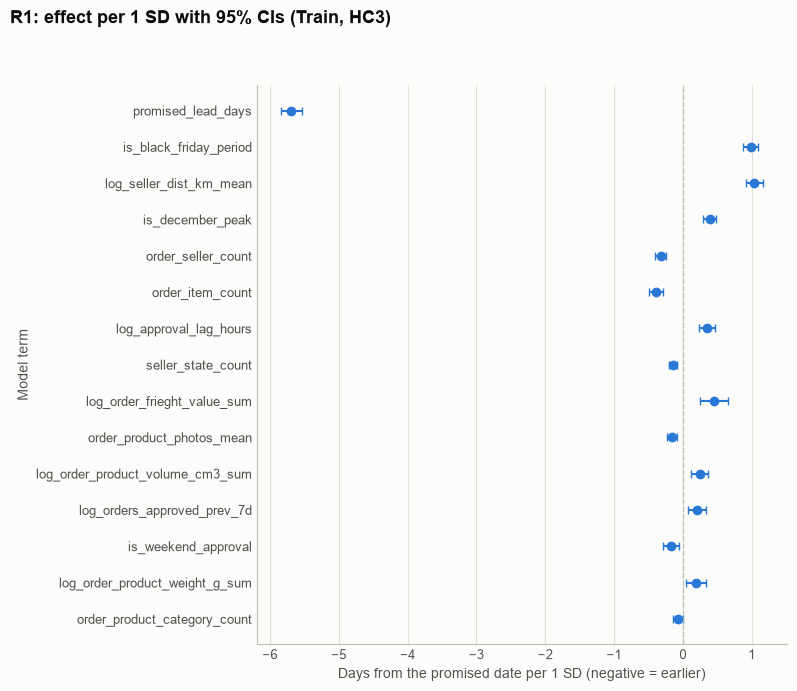

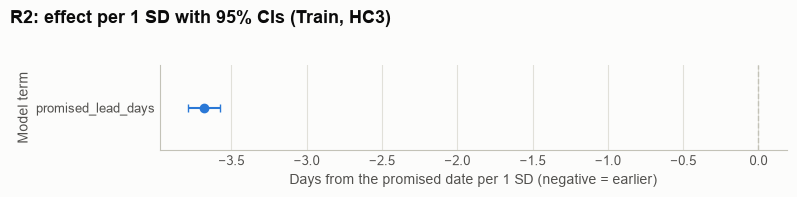

In [32]:
for label in ['R1', 'R2']:
    mf.plot_effects_forest(coef_tables[label], 'Days from the promised date per 1 SD (negative = earlier)',
                           FIG / f'03_{label.lower()}_effects.png',
                           title=f'{label}: effect per 1 SD with 95% CIs (Train, HC3)')
    plt.show()

### 9.2 Hypothesis check

The six feature-engineering hypotheses (time, workload, order, distance, payment, promise) with the expected sign on days late (positive = later arrival). A verdict of agree or disagree needs a significant coefficient (p < 0.05, HC3); otherwise "not significant", or "not in model" when stepwise dropped the feature.

In [33]:
hypothesis = hypothesis_check_table({'R1': coef_tables['R1'], 'R2': coef_tables['R2']})
hypothesis_view = hypothesis.assign(coef=hypothesis['coef'].round(3), p_value=hypothesis['p_value'].round(4))
display(hypothesis_view)
display(hypothesis.groupby(['model', 'verdict']).size().unstack(fill_value=0))

,hypothesis,feature,model,expected_sign,term,coef,p_value,observed_sign,verdict
0,time,is_weekend_approval,R1,+,is_weekend_approval,-0.173,0.0049,-,disagree
1,time,is_black_friday_period,R1,+,is_black_friday_period,0.983,0.0000,+,agree
2,time,is_december_peak,R1,+,is_december_peak,0.390,0.0000,+,agree
3,workload,orders_approved_prev_7d,R1,+,log_orders_approved_prev_7d,0.203,0.0017,+,agree
4,workload,approval_lag_hours,R1,+,log_approval_lag_hours,0.352,0.0000,+,agree
5,order,order_item_count,R1,+,order_item_count,-0.397,0.0000,-,disagree
6,order,order_seller_count,R1,+,order_seller_count,-0.323,0.0000,-,disagree
7,order,order_product_weight_g_sum,R1,+,log_order_product_weight_g_sum,0.187,0.0141,+,agree
8,order,order_product_volume_cm3_sum,R1,+,log_order_product_volume_cm3_sum,0.241,0.0001,+,agree
9,distance,seller_dist_km_mean,R1,+,log_seller_dist_km_mean,1.037,0.0000,+,agree


verdict,agree,disagree,not in model,not significant
model,,,,
R1,8,4,0,2
R2,1,0,13,0


### 9.3 OLS diagnostics

Residual against fitted value, a normal Q-Q plot, and residuals by route type and the most common customer states, for R1 on Train (in-sample residuals). Delivery delays have a long right tail and the spread depends on the order, which breaks the constant-variance and normality assumptions behind classical OLS standard errors. HC3 standard errors do not need constant variance, so the coefficient tables use them; the point estimates are unchanged. The Breusch-Pagan test and the residual SD by fitted-value group quantify the heteroscedasticity.

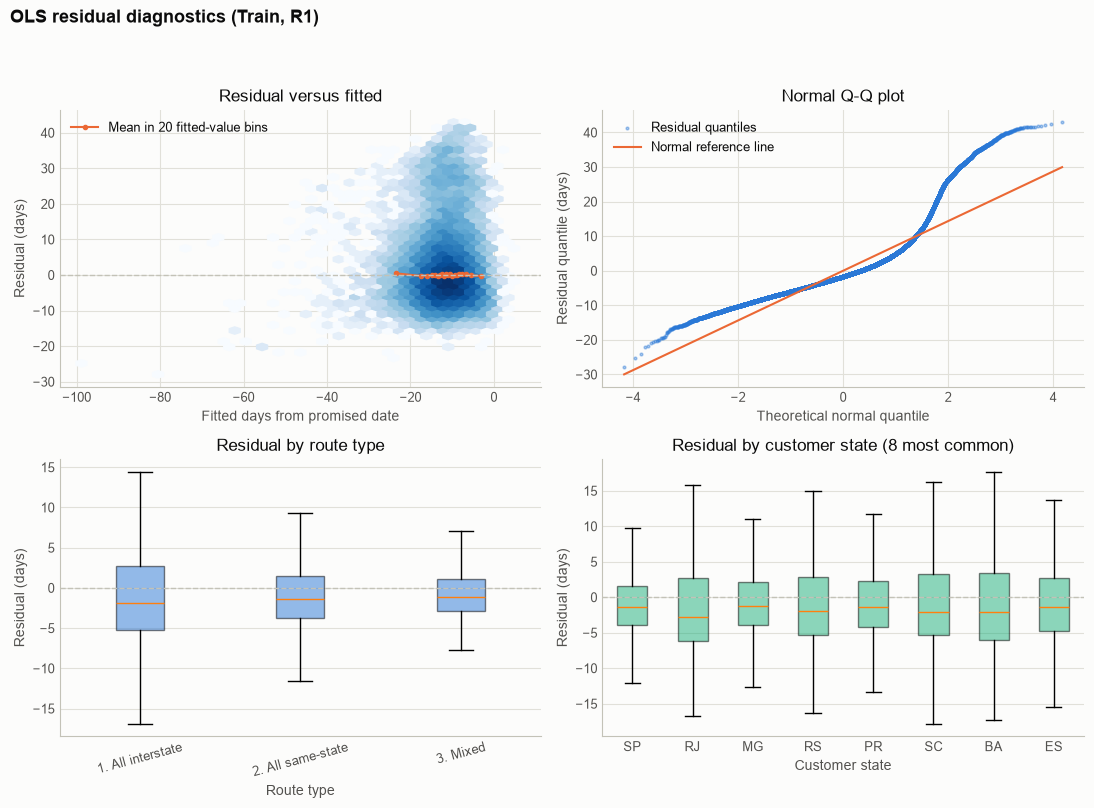

,Breusch-Pagan LM,p-value
0,940.293244,5.188163e-162


,Fitted-value group,mean_fitted,residual_mean,residual_sd,orders
0,1,-17.900,-0.013,8.325,9075
1,2,-13.169,-0.059,7.481,9074
2,3,-11.197,0.061,7.445,9074
3,4,-9.149,-0.047,7.648,9074
4,5,-5.778,0.057,8.515,9074


In [34]:
mf.plot_ols_diagnostics(sm_results['R1'].fittedvalues, sm_results['R1'].resid, data.train_df['route_type'],
                        data.train_df['customer_state'], FIG / '03_ols_diagnostics.png')
plt.show()
bp_summary, bp_groups = heteroscedasticity_table(sm_results['R1'])
display(bp_summary)
display(bp_groups.round(3))

### 9.4 Random Forest: permutation importance, partial dependence and agreement with the linear model

Permutation importance shuffles one raw feature at a time and measures the increase in RMSE (5 repeats): the Train-fitted R3 on Validation, and the June-fitted R3 on June. Partial-dependence plots show the average predicted days from the promise across the range of the top three features. The agreement table sets the forest's ten most important features beside the R1 coefficient significance. Permutation importance can understate correlated features and overstate those with many split points (Strobl et al., 2007, BMC Bioinformatics 8:25).

/Users/andrew_tjs/github/Team8_IT5006_Ecommerce_Analytics_AY2627Sem1/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


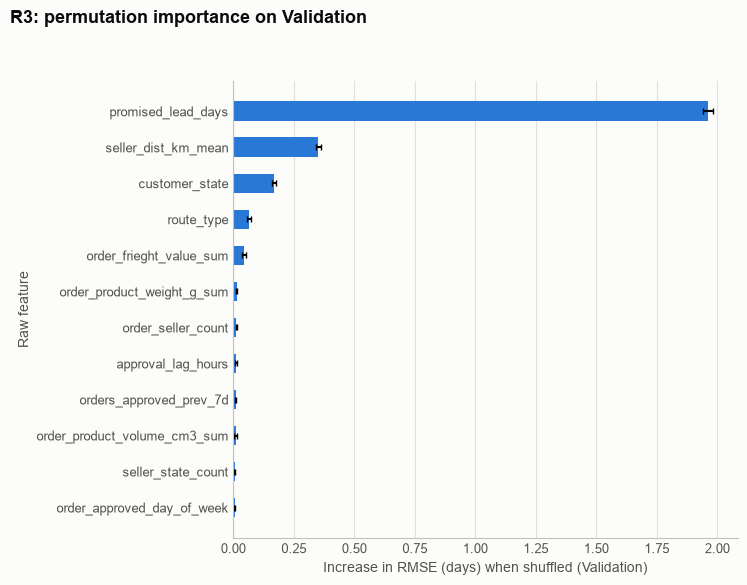

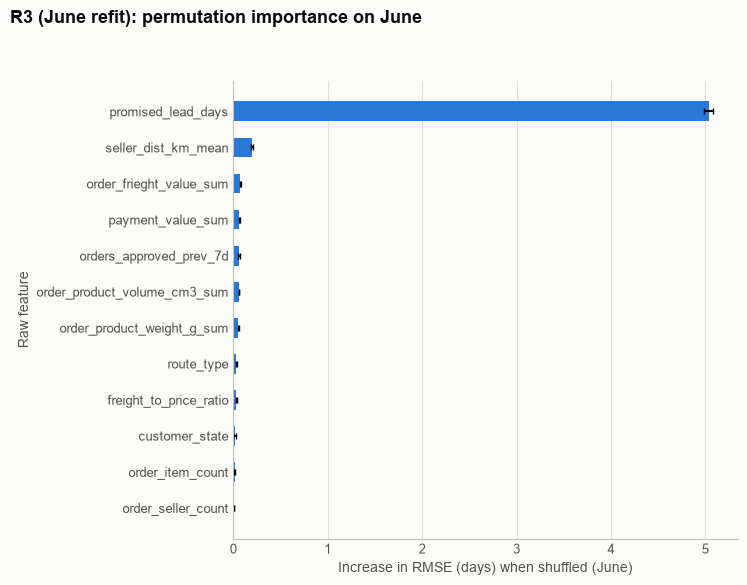

In [35]:
importance_validation = rf_permutation_importance(train_fits['R3'], data.X_validation, data.y_validation, SCORING)
june_X = final_df.set_index('order_id').loc[known_june['order_id'], FEATURES]
importance_june = rf_permutation_importance(june_fits['R3'], june_X, known_june['actual_target'].astype(float).to_numpy(), SCORING)
importance_validation.to_csv(OUT / 'rf_permutation_importance_validation.csv', index=False)
importance_june.to_csv(OUT / 'rf_permutation_importance_june.csv', index=False)
mf.plot_importance(importance_validation, 'Increase in RMSE (days) when shuffled (Validation)',
                   FIG / '03_rf_importance_validation.png', title='R3: permutation importance on Validation')
plt.show()
mf.plot_importance(importance_june, 'Increase in RMSE (days) when shuffled (June)',
                   FIG / '03_rf_importance_june.png', title='R3 (June refit): permutation importance on June')
plt.show()

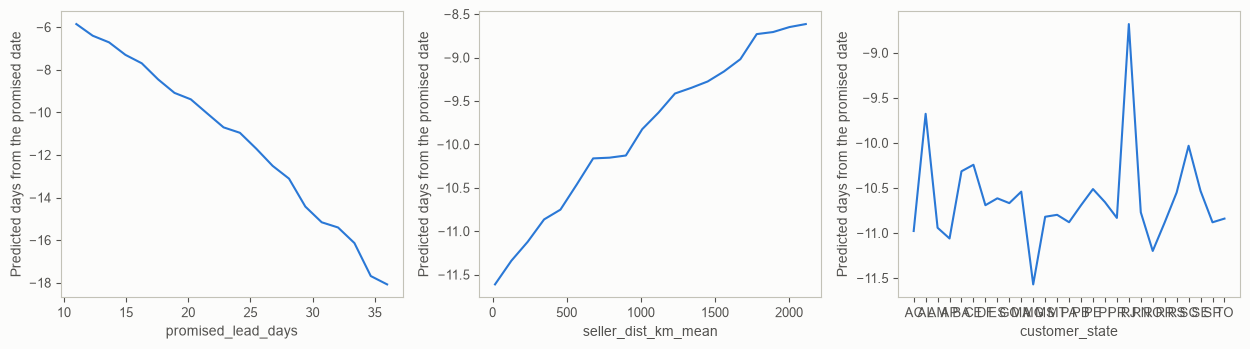

,rank,feature,importance_mean,linear_min_p,linear_significant
0,1,promised_lead_days,1.9618,0.0000,True
1,2,seller_dist_km_mean,0.3517,0.0000,True
2,3,customer_state,0.1664,0.0000,True
3,4,route_type,0.0637,0.0000,True
4,5,order_frieght_value_sum,0.0437,0.0000,True
5,6,order_product_weight_g_sum,0.0141,0.0141,True
6,7,order_seller_count,0.0129,0.0000,True
7,8,approval_lag_hours,0.0118,0.0000,True
8,9,orders_approved_prev_7d,0.0100,0.0017,True
9,10,order_product_volume_cm3_sum,0.0094,0.0001,True


In [36]:
top_features = importance_validation['feature'].head(3).tolist()
pdp = rf_partial_dependence(train_fits['R3'], data.X_validation.astype({c: float for c in data.num_cols}),
                            top_features, categorical=data.cat_cols)
plot_partial_dependence(pdp, 'Predicted days from the promised date', FIG / '03_rf_partial_dependence.png')
plt.show()
agreement = agreement_table(importance_validation, coef_tables['R1'])
agreement['importance_mean'] = agreement['importance_mean'].round(4)
agreement['linear_min_p'] = agreement['linear_min_p'].round(4)
display(agreement)

**Reading the interpretation.**
- **Coefficients (R1, HC3).** `promised_lead_days` dominates: -0.76 days against the promise per extra promised day (-5.7 days per SD), so a longer promise means earlier arrival relative to it. Farther sellers add delay (+0.54 days per doubling of mean seller distance), the Black Friday period adds about 1.0 day and the December peak 0.4 day. Order complexity goes against the hypothesis: more items (-0.40 days per SD), more sellers (-0.32) and a multi-state seller set (-0.15) go with earlier arrival, as in the classification notebook. R2 contains only the promise term (-0.49 days per day), so its table has two rows.
- **Hypotheses.** For R1, 8 of 14 expectations agree in sign and significance (Black Friday, December, both workload features, weight, volume, distance, promise), 4 disagree (weekend approval, item count, seller count, seller-state count) and 2 payment features are not significant. R2 retains only the promise.
- **Diagnostics.** Residual spread is not constant (Breusch-Pagan LM 940, p < 0.001; residual SD 8.3 days in the lowest fitted-value group, 7.4 to 7.6 in the middle groups and 8.5 in the highest) and the Q-Q plot shows the heavy right tail contributed by late orders, so classical standard errors would be unreliable; HC3 is used throughout. The point estimates, and therefore the predictions, are unaffected.
- **Random Forest.** Permutation importance on Validation is led by `promised_lead_days` (RMSE rises by 1.96 days when it is shuffled), then `seller_dist_km_mean`, `customer_state`, `route_type` and freight value. All ten of the forest's top features are also significant in R1, so the two model families agree on which features matter; the partial-dependence plots show the shapes for the top three.

## 10. Exports and run metadata

Report tables are exported as HTML, LaTeX and CSV with `export_report_tables`; `run_metadata.json` records dates, row counts, features, transformations, selections, forest parameters, package versions and model fingerprints for the summary notebook.

In [37]:
def table_item(title, frame, note='', prose=''):
    return {'title': title, 'frame': frame, 'note': note, 'prose': prose}


COMPARISON_NOTE = 'Train is in-sample; CV is mean +/- SD over 5 chronological folds; June is Test; July and August are Monitoring. Errors are in days.'
exports = {
    'regression_model_comparison': [table_item(f'Regression: {t}', tbl, COMPARISON_NOTE) for t, tbl in comparison_tables.items()],
    'regression_error_by_outcome': [table_item('Regression: RMSE and MAE for late versus on-time orders (days)', error_split)],
    'regression_late_flag': [table_item('Regression: derived late flag (prediction > 0 days) versus the classification label', late_flag)],
    'regression_success_criteria': [table_item('Regression: success criteria', criteria_display)],
    'regression_overfitting_gaps': [table_item('Regression: overfitting gap (Train minus CV mean)', gaps)],
    'regression_drift': [table_item('Regression: drift from June to August', drift_view)],
    'regression_rf_tuning_gain': [table_item(f"Random Forest: tuned minus default ({ml.display_name('R3')} minus {ml.display_name('R3d')})", tuning_gain.round(4),
                                             'Negative gain is better for RMSE and MAE. Gaps are Train minus CV mean.')],
    'regression_stepwise_path': [table_item('CV-stepwise path (CV RMSE in days)', rmse_path.round(4))],
    'regression_selection_overlap': [table_item('Variable selection overlap', overlap)],
    'regression_coefficients': [table_item('R2 coefficients (HC3, days)', effects_r2), table_item('R1 coefficients (HC3, days)', effects_r1)],
    'regression_hypothesis_check': [table_item('Hypothesis check', hypothesis_view)],
    'regression_ols_heteroscedasticity': [table_item('Breusch-Pagan test (R1)', bp_summary.round(4)),
                                          table_item('R1 residual spread by fitted-value group', bp_groups.round(3))],
    'regression_rf_search_summary': [table_item('Random Forest search space', space), table_item('Random Forest search summary', summary),
                                     table_item('Stage B top candidates', top_candidates)],
    'regression_rf_agreement': [table_item('Random Forest top features versus R1 significance', agreement)],
}
for stem, items in exports.items():
    export_report_tables(items, OUT, stem)
print(f'{len(exports)} table groups exported to {OUT}')

14 table groups exported to results/simple_to_complex/regression


In [38]:
def headline(label, split):
    row = results[(results['model'] == label) & (results['split'] == split)].iloc[0]
    return {k: float(row[k]) for k in ['rmse', 'mae', 'r2', 'median_ae', 'bias', 'late_flag_f1', 'late_rate']}


metadata = {
    'task': TASK, 'run_date': RUN_DATE, 'lookback_days': LOOKBACK, 'random_state': RANDOM_STATE,
    'dates': {'train': [str(data.train_df['order_approved_dt'].min()), str(data.train_df['order_approved_dt'].max())],
              'validation': [str(data.validation_df['order_approved_dt'].min()), str(data.validation_df['order_approved_dt'].max())],
              'test_june': ['2018-06-01', '2018-06-30'], 'monitoring': ['2018-07-01', '2018-08-31']},
    'row_counts': {**data.counts(), 'train_late': int((data.y_train > 0).sum()), 'validation_late': int((data.y_validation > 0).sum()),
                   'june_scored': len(june_ids), 'june_known': int(june_targets.notna().sum()),
                   'july_scored': len(monitoring['R0a']['2018-07']), 'august_scored': len(monitoring['R0a']['2018-08'])},
    'features': {'numeric': data.num_cols, 'categorical': data.cat_cols},
    'linear_transforms': {'log_cols': LOG_COLS, 'cyclic': True, 'merge_mixed_route': True, 'squared_cols': [],
                          'rule': 'pre-specified'},
    'selected_variables': {'R1': FEATURES, 'R2': R2_UNITS, 'R2B': BIC_UNITS, 'AIC': AIC_UNITS, 'Lasso': lasso['selected_units']},
    'stepwise': {'best_step': best_step, 'one_se_step': chosen_step, 'lasso_alpha': lasso['penalty']},
    'rf_best_params': RF_PARAMS, 'rf_search': {k: meta[k] for k in ['n_iter_stage_a', 'best_cv_mean', 'best_cv_sd', 'stage_a_seconds', 'stage_b_seconds']},
    'rf_default_params': {'n_estimators': 100, 'random_state': RANDOM_STATE, 'other': 'scikit-learn defaults'},
    'resampling': {'adopted': False, 'note': 'No resampling experiment and no reweighting for regression.'},
    'fingerprints': {label: f['before_june'] for label, f in fingerprints.items()},
    'coefficient_checks': coefficient_checks,
    'headline_june': {label: headline(label, 'June') for label in SPECS},
    'headline_validation': {label: headline(label, 'Validation') for label in SPECS},
    'versions': {'python': platform.python_version(), 'scikit-learn': sklearn.__version__, 'numpy': np.__version__,
                 'pandas': pd.__version__, 'statsmodels': statsmodels.__version__},
}
(OUT / 'run_metadata.json').write_text(json.dumps(metadata, indent=2, default=str))

9648